This project investigates whether objective game characteristics or user engagement metrics better explain variations in board game ratings, with the aim of understanding how players evaluate game quality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/games.csv")
df.head()

,id,type,name,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,minage,users_rated,average_rating,bayes_average_rating,total_owners,total_traders,total_wanters,total_wishers,total_comments,total_weights,average_weight
0,12333,boardgame,Twilight Struggle,2005.0,2.0,2.0,180.0,180.0,180.0,13.0,20113,8.33774,8.22186,26647,372,1219,5865,5347,2562,3.4785
1,120677,boardgame,Terra Mystica,2012.0,2.0,5.0,150.0,60.0,150.0,12.0,14383,8.28798,8.14232,16519,132,1586,6277,2526,1423,3.8939
2,102794,boardgame,Caverna: The Cave Farmers,2013.0,1.0,7.0,210.0,30.0,210.0,12.0,9262,8.28994,8.06886,12230,99,1476,5600,1700,777,3.7761
3,25613,boardgame,Through the Ages: A Story of Civilization,2006.0,2.0,4.0,240.0,240.0,240.0,12.0,13294,8.20407,8.05804,14343,362,1084,5075,3378,1642,4.1590
4,3076,boardgame,Puerto Rico,2002.0,2.0,5.0,150.0,90.0,150.0,12.0,39883,8.14261,8.04524,44362,795,861,5414,9173,5213,3.2943


In [3]:
df.shape


(81312, 20)

In [4]:
df.columns

Index(['id', 'type', 'name', 'yearpublished', 'minplayers', 'maxplayers',
       'playingtime', 'minplaytime', 'maxplaytime', 'minage', 'users_rated',
       'average_rating', 'bayes_average_rating', 'total_owners',
       'total_traders', 'total_wanters', 'total_wishers', 'total_comments',
       'total_weights', 'average_weight'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81312 entries, 0 to 81311
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    81312 non-null  int64  
 1   type                  81312 non-null  object 
 2   name                  81271 non-null  object 
 3   yearpublished         81309 non-null  float64
 4   minplayers            81309 non-null  float64
 5   maxplayers            81309 non-null  float64
 6   playingtime           81309 non-null  float64
 7   minplaytime           81309 non-null  float64
 8   maxplaytime           81309 non-null  float64
 9   minage                81309 non-null  float64
 10  users_rated           81312 non-null  int64  
 11  average_rating        81312 non-null  float64
 12  bayes_average_rating  81312 non-null  float64
 13  total_owners          81312 non-null  int64  
 14  total_traders         81312 non-null  int64  
 15  total_wanters      

In [6]:
df.describe()

,id,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,minage,users_rated,average_rating,bayes_average_rating,total_owners,total_traders,total_wanters,total_wishers,total_comments,total_weights,average_weight
count,81312.000000,81309.000000,81309.000000,81309.000000,81309.000000,81309.000000,81309.000000,81309.000000,81312.000000,81312.000000,81312.000000,81312.000000,81312.000000,81312.000000,81312.000000,81312.000000,81312.000000,81312.000000
mean,72278.150138,1806.630668,1.992018,5.637703,51.634788,49.276833,51.634788,6.983975,161.886585,4.212144,1.157632,262.502509,9.236423,12.688890,42.719144,49.290031,16.488009,0.908083
std,58818.237742,588.517834,0.931034,56.076890,345.699969,334.483934,345.699969,5.035138,1145.978126,3.056551,2.340033,1504.536693,39.757408,60.764207,239.292628,284.862853,115.980285,1.176002
min,1.000000,-3500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21339.750000,1984.000000,2.000000,2.000000,8.000000,10.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,43258.000000,2003.000000,2.000000,4.000000,30.000000,30.000000,30.000000,8.000000,2.000000,5.265620,0.000000,7.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,128836.500000,2010.000000,2.000000,6.000000,60.000000,60.000000,60.000000,12.000000,16.000000,6.718777,0.000000,51.000000,2.000000,3.000000,7.000000,9.000000,2.000000,1.916700
max,184451.000000,2018.000000,99.000000,11299.000000,60120.000000,60120.000000,60120.000000,120.000000,53680.000000,10.000000,8.221860,73188.000000,1395.000000,1586.000000,6402.000000,11798.000000,5996.000000,5.000000


Observations with invalid values (yearpublished ≤ 0) were removed to ensure data quality, as such entries are unlikely to represent real-world board games.

In [7]:
df = df[df['yearpublished'] > 0]
df = df[df['minplayers'] > 0]
df = df[df['playingtime'] > 0]

In [8]:
df = df.drop(['id', 'name', 'type'], axis=1)

In [9]:
df = df.dropna()

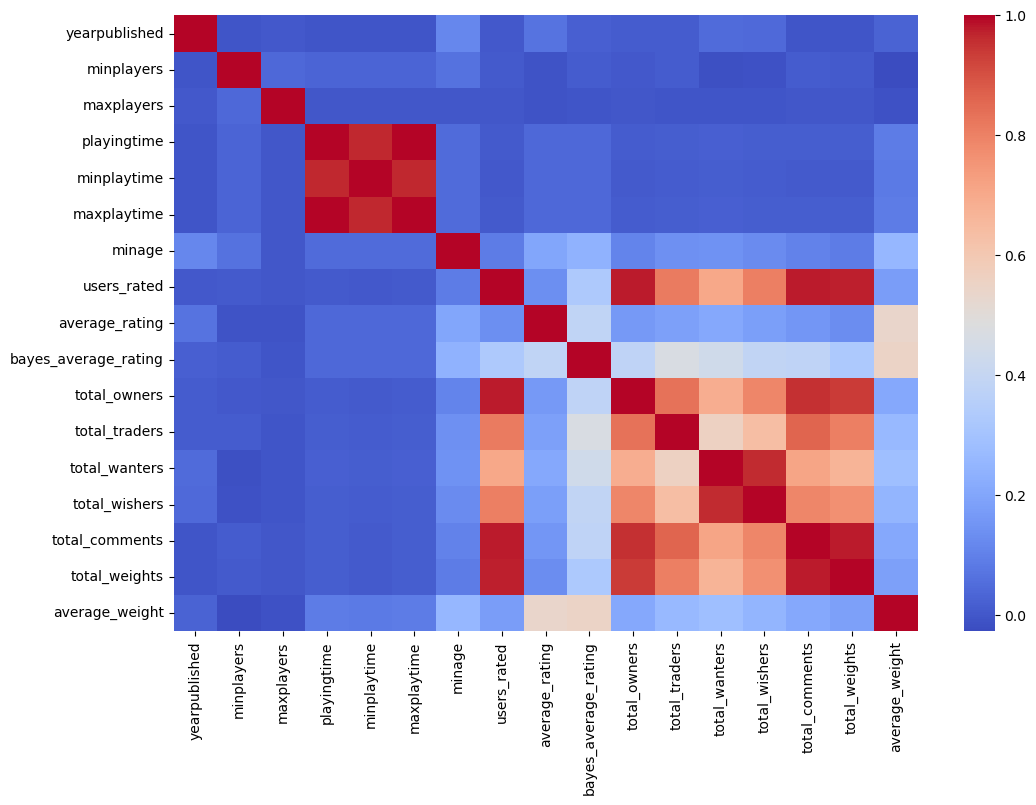

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

Correlation analysis indicates that game complexity (average_weight) has the strongest relationship with ratings, while variables such as player count and playtime exhibit negligible influence.

In [11]:
df.corr()['average_rating'].sort_values(ascending=False)

average_rating          1.000000
average_weight          0.537814
bayes_average_rating    0.383938
total_wanters           0.208517
minage                  0.200047
total_traders           0.183990
total_wishers           0.180834
total_owners            0.162713
total_comments          0.156535
users_rated             0.134815
total_weights           0.133382
yearpublished           0.068046
playingtime             0.040081
maxplaytime             0.040081
minplaytime             0.038562
minplayers             -0.007552
maxplayers             -0.008261
Name: average_rating, dtype: float64

In [12]:
X = df.drop('average_rating', axis=1)
y = df['average_rating']
X = X.drop('bayes_average_rating', axis=1)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.2998612082516465
MSE: 5.79086362147896


The relatively low explanatory power (R² ≈ 0.30) highlights the limitations of relying solely on quantitative features, suggesting that subjective elements such as theme, design quality, and player experience play a substantial role in shaping ratings.

##Conclusion

This analysis explored the factors influencing board game ratings using a regression-based approach. Correlation analysis revealed that game complexity (average weight) has the strongest positive relationship with ratings, suggesting that players tend to favour strategically rich games. In contrast, user engagement metrics such as ownership and wishlist counts showed only moderate correlations, indicating that popularity contributes to ratings but is not a dominant factor.

The regression model achieved an R² value of approximately 0.30, meaning that around 30% of the variation in ratings can be explained by the selected features. This suggests that while observable game attributes and engagement metrics provide some predictive power, a substantial portion of rating variability is likely driven by subjective factors such as player preferences, game design quality, and overall user experience.

The findings suggest that players prioritise depth and complexity over structural attributes such as duration or player count, while engagement metrics primarily reflect popularity rather than intrinsic quality. Notably, gameplay characteristics such as duration and player count exhibited minimal influence on ratings, challenging common assumptions about their importance.

Overall, these results highlight the complexity of user perception and suggest that incorporating qualitative features such as textual reviews or detailed gameplay mechanics—could significantly improve predictive performance in future work.